# Comparing Retrievals for Co-located TROPOMI and OCI Spectra

Pick **one TROPOMI orbit** from `co-location_results.json`, re-match dark OCI↔TROPOMI pixels from raw L1 with editable thresholds, then compare co-located L1 spectra and independent SIF retrievals:

- TROPOMI: `TROPOMI_RED_SIF_orbit_*.h5` (row-aware data-driven; `sif_red_pc1`)
- PACE OCI: `interim_*_svd_retrieval_*.nc`

In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from collections import defaultdict
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd
from scipy import constants

COLOC_ROOT = Path("/home/zhe2/FraLab/PACE_redSIF_PACE/TROPOMI_OCI_colocation")
sys.path.insert(0, str(COLOC_ROOT))

from colocation.config import Config
from colocation.match import match_one_swath

# ---- editable ----
CYCLE = "cycle1"  # "cycle1" | "cycle2"
ORBIT = None  # int for one orbit, or None = all co-located orbits in CYCLE
MAX_SWATHS = None  # e.g. 3 for a smoke test; None = all
COLOCATION_JSON = COLOC_ROOT / "notebooks" / "co-location_results.json"

TROP_RET_ROOT = Path("/net/squid/data1/projects/TROPOMI/red_sif_july2025_row_aware_v2")
TROP_RET_DIR = TROP_RET_ROOT / CYCLE / "retrieval"
PACE_RET_DIR = Path("/home/zhe2/data/PACE/svd_retrieval_output")

# unused by match_one_swath but required by Config
RSR_PATH = Path("/home/zhe2/data/MyProjects/PACE_redSIF_PACE/PACE_OCI/PACE_OCI_RSRs.nc")
SNR_PATH = Path(
    "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/PACE_OCI/PACE_OCI_L1BLUT_baseline_SNR_1.1.txt"
)

N_EXAMPLE_SPECTRA = 6
WL_PLOT_MIN, WL_PLOT_MAX = 665.0, 715.0
RNG = np.random.default_rng(0)

_PACE_STAMP_RE = re.compile(r"PACE_OCI\.(\d{8}T\d{6})")

## Flexible match thresholds

Core cuts go into `match_one_swath`. Extra keys are applied as post-filters on the returned pairs.

In [2]:
THRESHOLDS = {
    # match_one_swath
    "max_dist_km": 2.5,
    "max_dt_min": 30.0,
    "lt_max_oci": 30.0,
    "lt_mask_wl_min_oci": 600.0,
    "pace_stride_pix": 50,
    "tropo_scan_stride": 2,
    "tropo_pix_stride": 2,
    # post-filters (None = off)
    "max_abs_dvza_deg": 20.0,  # e.g. 5.0
    "max_sza_deg": 70.0,  # e.g. 70.0
    "require_both_retrieved": True,
    # TROPOMI_RED_SIF QC: "paper" | "exploratory" | "all"
    "trop_qc": "paper",
}

print("THRESHOLDS:")
for k, v in THRESHOLDS.items():
    print(f"  {k}: {v}")

THRESHOLDS:
  max_dist_km: 2.5
  max_dt_min: 30.0
  lt_max_oci: 30.0
  lt_mask_wl_min_oci: 600.0
  pace_stride_pix: 50
  tropo_scan_stride: 2
  tropo_pix_stride: 2
  max_abs_dvza_deg: 20.0
  max_sza_deg: 70.0
  require_both_retrieved: True
  trop_qc: paper


## Load orbit from co-location_results.json

In [3]:
with open(COLOCATION_JSON) as f:
    coloc = json.load(f)

meta = coloc["meta"]
pace_dir = Path(meta["pace_dir"])

if CYCLE not in {"cycle1", "cycle2"}:
    raise ValueError(f"CYCLE must be 'cycle1' or 'cycle2', got {CYCLE!r}")
TROP_RET_DIR = TROP_RET_ROOT / CYCLE / "retrieval"
if not TROP_RET_DIR.is_dir():
    raise FileNotFoundError(TROP_RET_DIR)

cycle_orbits = {
    int(p.stem.split("_")[-1])
    for p in TROP_RET_DIR.glob("TROPOMI_RED_SIF_orbit_*.h5")
}
if not cycle_orbits:
    raise FileNotFoundError(f"no TROPOMI_RED_SIF_orbit_*.h5 in {TROP_RET_DIR}")

swaths_all = coloc["swaths"]
if ORBIT is not None:
    swaths_all = [s for s in swaths_all if int(s["orbit"]) == int(ORBIT)]
    if not swaths_all:
        available = sorted({int(s["orbit"]) for s in coloc["swaths"]})
        raise ValueError(
            f"Orbit {ORBIT} not in {COLOCATION_JSON.name}; available e.g. {available[:10]}..."
        )

jobs = []
skipped = []
for s in swaths_all:
    orb = int(s["orbit"])
    if orb not in cycle_orbits:
        skipped.append(orb)
        continue
    trop_l1 = Path(s["tropomi_path"])
    pace_l1 = [pace_dir / name for name in s["pace_granules"]]
    trop_ret = TROP_RET_DIR / f"TROPOMI_RED_SIF_orbit_{orb}.h5"
    miss_pace = [p for p in pace_l1 if not p.is_file()]
    if not trop_l1.is_file() or miss_pace or not trop_ret.is_file():
        skipped.append(orb)
        continue
    jobs.append(
        {
            "orbit": orb,
            "swath": s,
            "tropomi_path": trop_l1,
            "pace_paths": pace_l1,
            "trop_ret_path": trop_ret,
        }
    )

if MAX_SWATHS is not None:
    jobs = jobs[: int(MAX_SWATHS)]
if not jobs:
    raise RuntimeError(
        f"No usable swaths for CYCLE={CYCLE} ORBIT={ORBIT} "
        f"(skipped {len(skipped)}: missing L1 or retrieval)"
    )


def resolve_pace_ret(stamp: str) -> Path | None:
    gpu = PACE_RET_DIR / f"interim_{stamp}_svd_retrieval_full_gpu.nc"
    if gpu.is_file():
        return gpu
    par = PACE_RET_DIR / f"interim_{stamp}_svd_retrieval_full_parallel.nc"
    if par.is_file():
        return par
    cands = sorted(PACE_RET_DIR.glob(f"interim_{stamp}_svd_retrieval_*.nc"))
    return cands[0] if cands else None


def stamp_from_pace_path(path: str | Path) -> str:
    m = _PACE_STAMP_RE.search(Path(path).name)
    if not m:
        raise ValueError(f"Cannot parse PACE stamp from {path}")
    return m.group(1)


print(f"CYCLE={CYCLE}  ORBIT={ORBIT!r}  swaths to match={len(jobs)}")
print(f"  TROPOMI ret dir: {TROP_RET_DIR}")
print(f"  skipped (not in cycle or missing files): {len(skipped)}")
print("  orbits:", ", ".join(str(j["orbit"]) for j in jobs[:12]) + (" ..." if len(jobs) > 12 else ""))

CYCLE=cycle1  ORBIT=None  swaths to match=86
  TROPOMI ret dir: /net/squid/data1/projects/TROPOMI/red_sif_july2025_row_aware_v2/cycle1/retrieval
  skipped (not in cycle or missing files): 0
  orbits: 39989, 39990, 39991, 39992, 39993, 39994, 39995, 39996, 39997, 39998, 39999, 40000 ...


## Pixel match (raw L1)

In [ ]:
cfg = Config(
    pace_dir=pace_dir,
    tropomi_dir=Path(meta["tropomi_dir"]),
    rsr_path=RSR_PATH,
    snr_path=SNR_PATH,
    output_dir=Path("/tmp/oci_tropomi_compare_nb"),
    max_dist_km=float(THRESHOLDS["max_dist_km"]),
    max_dt_min=float(THRESHOLDS["max_dt_min"]),
    lt_max_oci=float(THRESHOLDS["lt_max_oci"]),
    lt_mask_wl_min_oci=float(THRESHOLDS["lt_mask_wl_min_oci"]),
    pace_stride_pix=int(THRESHOLDS["pace_stride_pix"]),
    tropo_scan_stride=int(THRESHOLDS["tropo_scan_stride"]),
    tropo_pix_stride=int(THRESHOLDS["tropo_pix_stride"]),
)

parts = []
for sid, job in enumerate(jobs):
    part = match_one_swath(
        cfg, job["tropomi_path"], job["pace_paths"], swath_id=sid
    )
    if part is None:
        print(f"  orbit {job['orbit']}: no matches")
        continue
    n = int(part["dist_km"].size)
    part["orbit"] = np.full(n, job["orbit"], dtype=np.int32)
    parts.append(part)

if not parts:
    raise RuntimeError(f"No matches for CYCLE={CYCLE} with current THRESHOLDS")

keys = [k for k in parts[0] if k not in ()]
m = {k: np.concatenate([p[k] for p in parts]) for k in keys}

n_raw = int(m["dist_km"].size)
print(f"Raw matches: {n_raw:,} from {len(parts)} swaths (CYCLE={CYCLE})")

dvza = np.abs(np.asarray(m["pace_vza"], dtype=float) - np.asarray(m["trop_vza"], dtype=float))
sel = np.ones(n_raw, dtype=bool)

max_dvza = THRESHOLDS.get("max_abs_dvza_deg")
if max_dvza is not None:
    sel &= dvza <= float(max_dvza)
    print(f"  after max_abs_dvza_deg={max_dvza}: {int(sel.sum()):,}")

max_sza = THRESHOLDS.get("max_sza_deg")
if max_sza is not None:
    sel &= (np.asarray(m["pace_sza"], dtype=float) <= float(max_sza)) & (
        np.asarray(m["trop_sza"], dtype=float) <= float(max_sza)
    )
    print(f"  after max_sza_deg={max_sza}: {int(sel.sum()):,}")

print(f"Pairs after geo post-filters (before retrieval gate): {int(sel.sum()):,}")

/home/zhe2/FraLab/PACE_redSIF_PACE/TROPOMI_OCI_colocation/colocation/match.py:37: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(tropomi_path) as ds:
/home/zhe2/FraLab/PACE_redSIF_PACE/TROPOMI_OCI_colocation/colocation/match.py:91: RuntimeWarning: All-NaN slice encountered
  lt_max = np.nanmax(lt, axis=0)


  swath 0: kept 346  (S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc)
  swath 1: kept 359  (S5P_OFFL_L1B_RA_BD5_20250702T014030_20250702T032200_39990_03_020101_20250702T051259.nc)
  swath 2: kept 236  (S5P_OFFL_L1B_RA_BD5_20250702T032200_20250702T050330_39991_03_020101_20250702T065259.nc)
  swath 3: kept 218  (S5P_OFFL_L1B_RA_BD5_20250702T050330_20250702T064500_39992_03_020101_20250702T083312.nc)
  swath 4: kept 336  (S5P_OFFL_L1B_RA_BD5_20250702T064500_20250702T082630_39993_03_020101_20250702T101326.nc)
  swath 5: kept 249  (S5P_OFFL_L1B_RA_BD5_20250702T082630_20250702T100800_39994_03_020101_20250702T115331.nc)
  swath 6: kept 303  (S5P_OFFL_L1B_RA_BD5_20250702T100800_20250702T114930_39995_03_020101_20250702T133344.nc)
  swath 7: kept 324  (S5P_OFFL_L1B_RA_BD5_20250702T114930_20250702T133059_39996_03_020101_20250702T151355.nc)
  swath 8: kept 426  (S5P_OFFL_L1B_RA_BD5_20250702T133059_20250702T151229_39997_03_020101_20250702T165434.nc)


## Join independent SIF retrievals

Index convention (0-based L1 indices; lat/lon-validated):
- TROPOMI `TROPOMI_RED_SIF_orbit_*.h5`: flat table; `detector_row == trop_pix`, `scanline == trop_scan`. SIF = `coefficient[..., sif_red_pc1]`; χ² = `reduced_chi_square`. QC via `accepted_paper` / `accepted_exploratory` (`THRESHOLDS["trop_qc"]`).
- PACE interim NC: `sif_radiance_678nm[pace_scan, pace_pix]` (`source_*` = 1..N contiguous)

In [ ]:
trop_scan = np.asarray(m["trop_scan"], dtype=np.int32)
trop_pix = np.asarray(m["trop_pix"], dtype=np.int32)
pace_scan = np.asarray(m["pace_scan"], dtype=np.int32)
pace_pix = np.asarray(m["pace_pix"], dtype=np.int32)
pace_path_arr = np.asarray(m["pace_path"])
trop_path_arr = np.asarray(m["tropomi_path"])
orbits = np.asarray(m["orbit"], dtype=np.int32)

sif_trop = np.full(n_raw, np.nan, dtype=np.float64)
chi2_trop = np.full(n_raw, np.nan, dtype=np.float64)
retrieved_trop = np.zeros(n_raw, dtype=bool)

trop_qc = str(THRESHOLDS.get("trop_qc", "paper")).lower()
n_trop_miss = 0

by_orbit: dict[int, list[int]] = defaultdict(list)
for i, orb in enumerate(orbits):
    by_orbit[int(orb)].append(i)

for orb, idxs in by_orbit.items():
    trop_ret_path = TROP_RET_DIR / f"TROPOMI_RED_SIF_orbit_{orb}.h5"
    with h5py.File(trop_ret_path, "r") as f:
        names = [
            x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
            for x in f["state_name"][:]
        ]
        i_sif = names.index("sif_red_pc1")
        sif_flat = np.asarray(f["coefficient"][:, i_sif], dtype=np.float64)
        chi2_flat = np.asarray(f["reduced_chi_square"][:], dtype=np.float64)
        det_row = np.asarray(f["detector_row"][:], dtype=np.int32)
        det_scan = np.asarray(f["scanline"][:], dtype=np.int32)
        if trop_qc == "paper" and "accepted_paper" in f:
            qc_flat = np.asarray(f["accepted_paper"][:], dtype=np.uint8) > 0
        elif trop_qc == "exploratory" and "accepted_exploratory" in f:
            qc_flat = np.asarray(f["accepted_exploratory"][:], dtype=np.uint8) > 0
        else:
            qc_flat = np.isfinite(sif_flat)
        lut = {int(r) * 100_000 + int(s): j for j, (r, s) in enumerate(zip(det_row, det_scan))}
    for i in idxs:
        j = lut.get(int(trop_pix[i]) * 100_000 + int(trop_scan[i]))
        if j is None:
            n_trop_miss += 1
            continue
        sif_trop[i] = sif_flat[j]
        chi2_trop[i] = chi2_flat[j]
        retrieved_trop[i] = bool(qc_flat[j]) and np.isfinite(sif_flat[j])

print(
    f"TROPOMI_RED_SIF {CYCLE}: trop_qc={trop_qc!r}  "
    f"orbits={len(by_orbit)}  index misses={n_trop_miss:,}"
)

sif_pace = np.full(n_raw, np.nan, dtype=np.float64)
chi2_pace = np.full(n_raw, np.nan, dtype=np.float64)
converged_pace = np.zeros(n_raw, dtype=bool)

by_stamp: dict[str, list[int]] = defaultdict(list)
for i in range(n_raw):
    by_stamp[stamp_from_pace_path(pace_path_arr[i])].append(i)

n_pace_file_miss = 0
for stamp, idxs in by_stamp.items():
    ret_path = resolve_pace_ret(stamp)
    idxs = np.asarray(idxs, dtype=np.int64)
    if ret_path is None:
        n_pace_file_miss += int(idxs.size)
        continue
    with nc.Dataset(ret_path) as ds:
        sif = np.asarray(ds["sif_radiance_678nm"][:], dtype=np.float64)
        chi2 = np.asarray(ds["reduced_chi2"][:], dtype=np.float64)
        if "converged" in ds.variables:
            conv = np.asarray(ds["converged"][:], dtype=np.uint8) > 0
        else:
            conv = np.isfinite(sif)
        sc = pace_scan[idxs]
        px = pace_pix[idxs]
        ok = (sc >= 0) & (px >= 0) & (sc < sif.shape[0]) & (px < sif.shape[1])
        jj = idxs[ok]
        sif_pace[jj] = sif[sc[ok], px[ok]]
        chi2_pace[jj] = chi2[sc[ok], px[ok]]
        converged_pace[jj] = conv[sc[ok], px[ok]]

both_ok = (
    retrieved_trop
    & converged_pace
    & np.isfinite(sif_trop)
    & np.isfinite(sif_pace)
)
print(
    f"Retrieval hits: trop={int(retrieved_trop.sum()):,}  "
    f"pace={int(converged_pace.sum()):,}  both={int(both_ok.sum()):,}"
    + (f"  pace file miss={n_pace_file_miss:,}" if n_pace_file_miss else "")
)

if THRESHOLDS.get("require_both_retrieved", True):
    sel = sel & both_ok
    print(f"After require_both_retrieved: {int(sel.sum()):,}")

if int(sel.sum()) == 0:
    raise RuntimeError("No pairs left after filters — loosen THRESHOLDS")

idx = np.flatnonzero(sel)
print(f"Final selected pairs: {idx.size:,}")

TROPOMI_RED_SIF: trop_qc='paper'  index misses=174
Retrieval hits: trop=89  pace=235  both=60
After require_both_retrieved: 31
Final selected pairs: 31


## Match QA

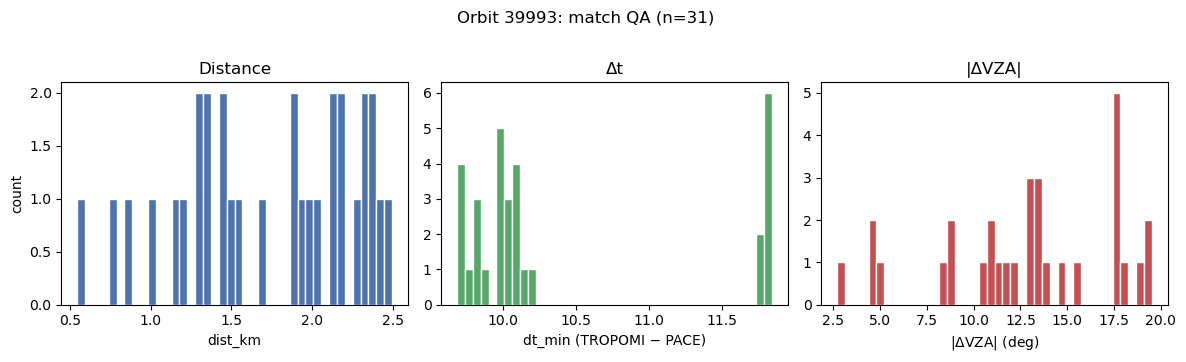

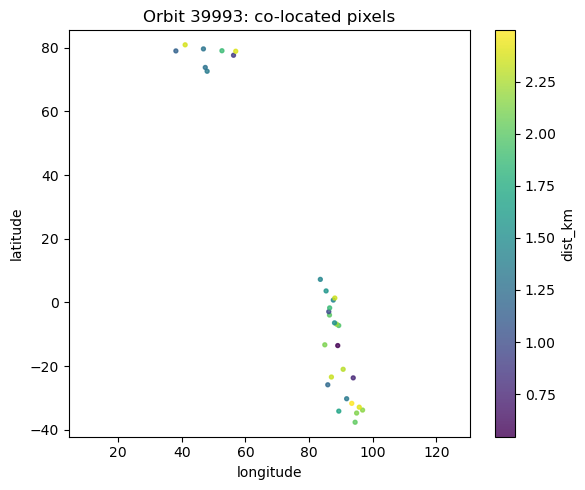

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(m["dist_km"][idx], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("dist_km")
axes[0].set_ylabel("count")
axes[0].set_title("Distance")

axes[1].hist(m["dt_min"][idx], bins=40, color="#55A868", edgecolor="white")
axes[1].set_xlabel("dt_min (TROPOMI − PACE)")
axes[1].set_title("Δt")

axes[2].hist(dvza[idx], bins=40, color="#C44E52", edgecolor="white")
axes[2].set_xlabel(r"$|\Delta$VZA$|$ (deg)")
axes[2].set_title("|ΔVZA|")

fig.suptitle(f"CYCLE={CYCLE}: match QA (n={idx.size:,})", y=1.02)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    m["pace_lon"][idx],
    m["pace_lat"][idx],
    c=m["dist_km"][idx],
    s=8,
    cmap="viridis",
    alpha=0.8,
)
cb = fig.colorbar(sc, ax=ax, label="dist_km")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Orbit {ORBIT}: co-located pixels")
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()

## Load L1 spectra for example matches

In [ ]:
def tropomi_mol_to_mW(radiance_mol, wavelength_nm):
    """mol s^-1 m^-2 nm^-1 sr^-1 → mW m^-2 nm^-1 sr^-1."""
    h, c_light, Na = constants.h, constants.c, constants.N_A
    return radiance_mol * (h * c_light * Na / wavelength_nm) * 1e9 * 1e3


def load_tropomi_spectrum(path: Path, scan: int, pix: int):
    with nc.Dataset(path) as ds:
        obs = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
        inst = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]
        wl = np.asarray(inst["nominal_wavelength"][0, pix, :], dtype=float)
        rad = np.asarray(obs["radiance"][0, scan, pix, :], dtype=float)
    lt = tropomi_mol_to_mW(rad, wl)
    return wl, lt


def load_oci_spectrum(path: Path, scan: int, pix: int):
    with nc.Dataset(path) as ds:
        wl = np.asarray(ds["sensor_band_parameters"]["red_wavelength"][:], dtype=float)
        f0 = np.asarray(ds["sensor_band_parameters"]["red_solar_irradiance"][:], dtype=float)
        esd = float(getattr(ds, "earth_sun_distance_correction", 1.0))
        sza = float(ds["geolocation_data"]["solar_zenith"][scan, pix])
        rhot = np.asarray(ds["observation_data"]["rhot_red"][:, scan, pix], dtype=float)
    rhot = np.where(rhot > 0, rhot, np.nan)
    mu0 = np.cos(np.deg2rad(sza))
    mu0 = mu0 if mu0 > 1e-6 else np.nan
    lt = rhot * f0 * mu0 / (np.pi * esd)  # W m^-2 sr^-1 µm^-1
    # → mW m^-2 nm^-1 sr^-1  (1 W/µm = 1 mW/nm)
    return wl, lt, sza


n_ex = min(N_EXAMPLE_SPECTRA, idx.size)
example_i = np.sort(RNG.choice(idx, size=n_ex, replace=False))

examples = []
for i in example_i:
    trop_l1 = Path(str(trop_path_arr[i]))
    p_path = Path(str(pace_path_arr[i]))
    wl_t, lt_t = load_tropomi_spectrum(trop_l1, int(trop_scan[i]), int(trop_pix[i]))
    wl_o, lt_o, _ = load_oci_spectrum(p_path, int(pace_scan[i]), int(pace_pix[i]))
    examples.append(
        {
            "i": int(i),
            "trop_scan": int(trop_scan[i]),
            "trop_pix": int(trop_pix[i]),
            "pace_scan": int(pace_scan[i]),
            "pace_pix": int(pace_pix[i]),
            "pace_name": Path(str(pace_path_arr[i])).name,
            "dist_km": float(m["dist_km"][i]),
            "dt_min": float(m["dt_min"][i]),
            "lat": float(m["pace_lat"][i]),
            "lon": float(m["pace_lon"][i]),
            "sif_trop": float(sif_trop[i]),
            "sif_pace": float(sif_pace[i]),
            "chi2_trop": float(chi2_trop[i]),
            "chi2_pace": float(chi2_pace[i]),
            "wl_trop": wl_t,
            "lt_trop": lt_t,
            "wl_oci": wl_o,
            "lt_oci": lt_o,
        }
    )

print(f"Loaded {len(examples)} example spectra")

/tmp/ipykernel_933847/638444404.py:8: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(path) as ds:


Loaded 6 example spectra


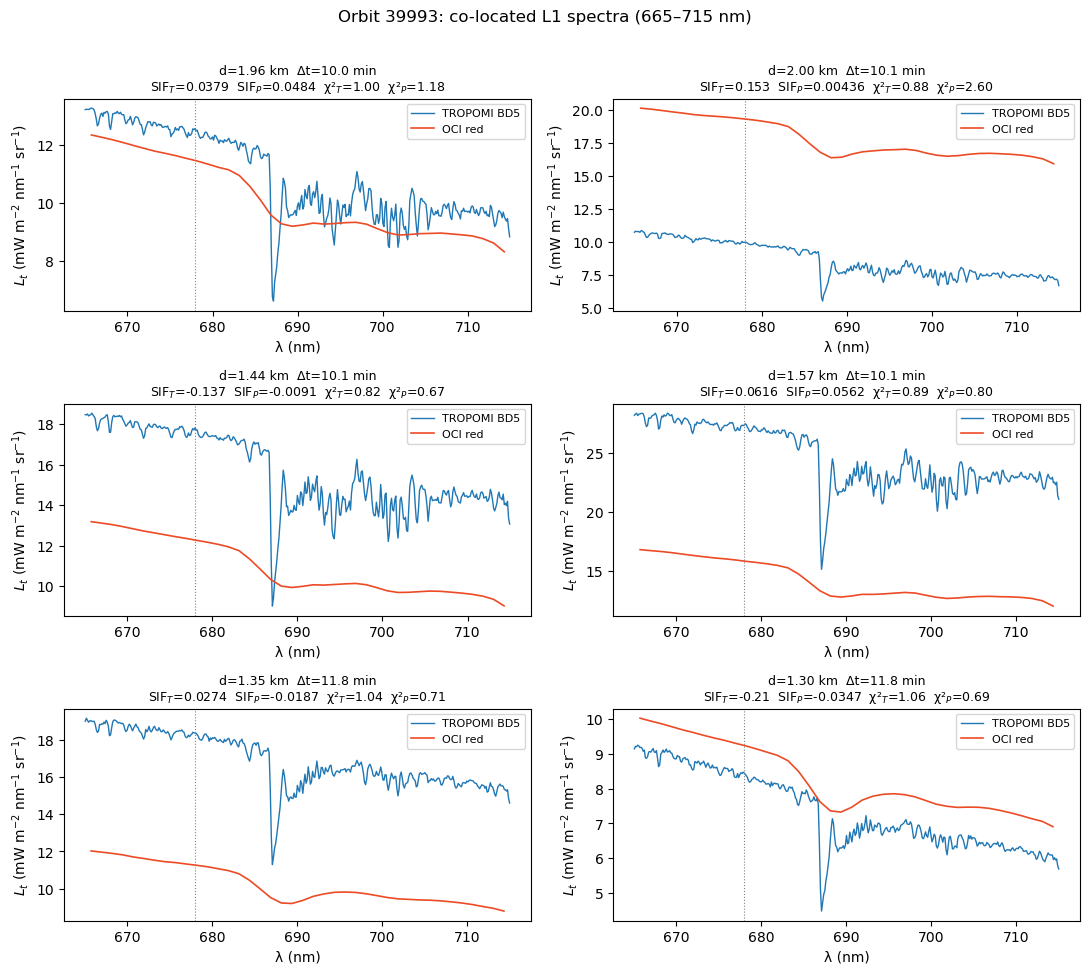

In [ ]:
ncols = 2
nrows = int(np.ceil(len(examples) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows), squeeze=False)

for ax, ex in zip(axes.ravel(), examples):
    mt = (ex["wl_trop"] >= WL_PLOT_MIN) & (ex["wl_trop"] <= WL_PLOT_MAX) & np.isfinite(ex["lt_trop"])
    mo = (ex["wl_oci"] >= WL_PLOT_MIN) & (ex["wl_oci"] <= WL_PLOT_MAX) & np.isfinite(ex["lt_oci"])
    ax.plot(ex["wl_trop"][mt], ex["lt_trop"][mt], color="#1f77b4", lw=1.0, label="TROPOMI BD5")
    ax.plot(ex["wl_oci"][mo], ex["lt_oci"][mo], color="#EC4B26", lw=1.2, label="OCI red")
    ax.axvline(678.0, color="gray", ls=":", lw=0.8)
    ax.set_xlabel("λ (nm)")
    ax.set_ylabel(r"$L_t$ (mW m$^{-2}$ nm$^{-1}$ sr$^{-1}$)")
    ax.set_title(
        f"d={ex['dist_km']:.2f} km  Δt={ex['dt_min']:.1f} min\n"
        f"SIF$_T$={ex['sif_trop']:.3g}  SIF$_P$={ex['sif_pace']:.3g}  "
        f"χ²$_T$={ex['chi2_trop']:.2f}  χ²$_P$={ex['chi2_pace']:.2f}",
        fontsize=9,
    )
    ax.legend(fontsize=8, loc="upper right")

for ax in axes.ravel()[len(examples) :]:
    ax.set_visible(False)

fig.suptitle(
    f"Orbit {ORBIT}: co-located L1 spectra ({WL_PLOT_MIN:.0f}–{WL_PLOT_MAX:.0f} nm)",
    y=1.01,
)
fig.tight_layout()
plt.show()

## SIF and χ² comparison

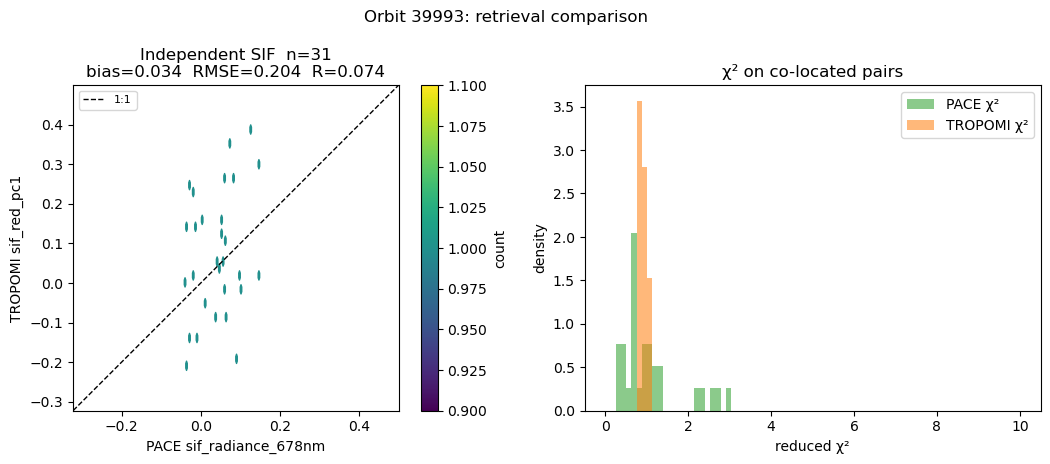

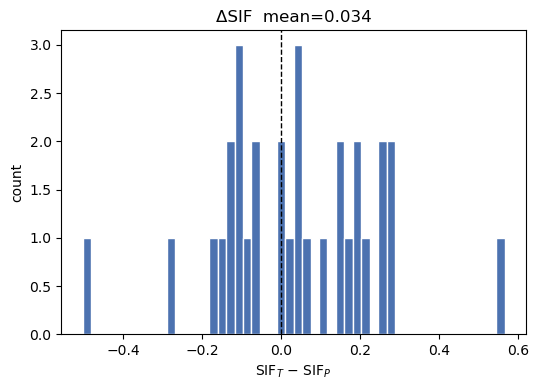

In [ ]:
x = sif_pace[idx]
y = sif_trop[idx]
finite = np.isfinite(x) & np.isfinite(y)
x, y = x[finite], y[finite]

bias = float(np.mean(y - x))
rmse = float(np.sqrt(np.mean((y - x) ** 2)))
r = float(np.corrcoef(x, y)[0, 1]) if x.size > 1 else np.nan

lo = float(np.nanpercentile(np.concatenate([x, y]), 1))
hi = float(np.nanpercentile(np.concatenate([x, y]), 99))
pad = 0.05 * (hi - lo + 1e-9)
lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
hb = ax.hexbin(x, y, gridsize=50, cmap="viridis", mincnt=1)
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("PACE sif_radiance_678nm")
ax.set_ylabel("TROPOMI sif_red_pc1")
ax.set_title(f"Independent SIF  n={x.size:,}\nbias={bias:.3g}  RMSE={rmse:.3g}  R={r:.3f}")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(hb, ax=ax, label="count")

ax = axes[1]
c2t = chi2_trop[idx]
c2p = chi2_pace[idx]
bins = np.linspace(0, 10, 80)
ax.hist(c2p[np.isfinite(c2p)], bins=bins, alpha=0.55, color="#2ca02c", label="PACE χ²", density=True)
ax.hist(c2t[np.isfinite(c2t)], bins=bins, alpha=0.55, color="#ff7f0e", label="TROPOMI χ²", density=True)
ax.set_xlabel("reduced χ²")
ax.set_ylabel("density")
ax.set_title("χ² on co-located pairs")
ax.legend()

fig.suptitle(f"CYCLE={CYCLE}: retrieval comparison", y=1.02)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(y - x, bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("SIF$_T$ − SIF$_P$")
ax.set_ylabel("count")
ax.set_title(f"ΔSIF  mean={bias:.3g}")
fig.tight_layout()
plt.show()

## Example match table

In [ ]:
rows = []
for ex in examples:
    rows.append(
        {
            "match_i": ex["i"],
            "trop_scan": ex["trop_scan"],
            "trop_pix": ex["trop_pix"],
            "pace_scan": ex["pace_scan"],
            "pace_pix": ex["pace_pix"],
            "dist_km": round(ex["dist_km"], 3),
            "dt_min": round(ex["dt_min"], 2),
            "lat": round(ex["lat"], 3),
            "lon": round(ex["lon"], 3),
            "sif_trop": ex["sif_trop"],
            "sif_pace": ex["sif_pace"],
            "chi2_trop": ex["chi2_trop"],
            "chi2_pace": ex["chi2_pace"],
            "pace_granule": ex["pace_name"],
        }
    )

df = pd.DataFrame(rows)
display(df)

print("\nTHRESHOLDS used:")
for k, v in THRESHOLDS.items():
    print(f"  {k}: {v}")
print(f"\nFinal n={idx.size:,}  SIF bias(T−P)={bias:.4g}  RMSE={rmse:.4g}  R={r:.4f}")

,match_i,trop_scan,trop_pix,pace_scan,pace_pix,dist_km,dt_min,lat,lon,sif_trop,sif_pace,chi2_trop,chi2_pace,pace_granule
0,168,1408,132,450,850,1.955,9.98,-7.264,89.297,0.037868,0.048442,1.004460,1.178508,PACE_OCI.20250702T071459.L1B.V3.nc
1,190,1488,86,800,650,1.996,10.08,-3.968,86.396,0.153137,0.004356,0.882312,2.604164,PACE_OCI.20250702T071459.L1B.V3.nc
2,207,1570,134,1200,850,1.440,10.06,0.728,87.591,-0.136712,-0.009104,0.817714,0.667680,PACE_OCI.20250702T071459.L1B.V3.nc
3,224,1638,98,1500,700,1.569,10.13,3.606,85.329,0.061619,0.056159,0.893129,0.804152,PACE_OCI.20250702T071459.L1B.V3.nc
4,252,3074,162,950,500,1.347,11.84,72.624,47.952,0.027380,-0.018732,1.040602,0.710889,PACE_OCI.20250702T073459.L1B.V3.nc
5,266,3186,288,1500,850,1.296,11.80,79.648,46.790,-0.209893,-0.034680,1.055655,0.689195,PACE_OCI.20250702T073459.L1B.V3.nc



THRESHOLDS used:
  max_dist_km: 2.5
  max_dt_min: 30.0
  lt_max_oci: 30.0
  lt_mask_wl_min_oci: 600.0
  pace_stride_pix: 50
  tropo_scan_stride: 2
  tropo_pix_stride: 2
  max_abs_dvza_deg: 20.0
  max_sza_deg: 70.0
  require_both_retrieved: True
  trop_qc: paper

Final n=31  SIF bias(T−P)=0.03403  RMSE=0.2042  R=0.0737
